## Task 1 – Data Quality Issues Identification

**The dataset contains 10,000 rows and 8 columns. Several data quality issues were found:**
- Missing values exist in multiple columns, especially Location (3265) and Payment Method (2579)
- Invalid entries like 'ERROR' and 'UNKNOWN' appear in Item, Payment Method, Location, and Total Spent
- Quantity, Price Per Unit, and Total Spent were stored as object type instead of numeric
- No duplicate rows were found

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style='whitegrid')

df = pd.read_csv("dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## Task 2 - Data Quality Assessment

In [2]:
df.shape

(10000, 8)

In [3]:
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [4]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [5]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:10])

Transaction ID
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' 'TXN_7034554' 'TXN_3160411'
 'TXN_2602893' 'TXN_4433211' 'TXN_6699534' 'TXN_4717867' 'TXN_2064365']
Item
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice']
Quantity
[ 2.  4.  5.  3.  1. nan]
Price Per Unit
[2.  3.  1.  5.  4.  1.5 nan]
Total Spent
[ 4. 12. nan 10. 20.  9. 16. 15. 25.  8.]
Payment Method
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
Location
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
Transaction Date
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31']


**After converting data types, Quantity, Price Per Unit, and Total Spent became float64
and Transaction Date became datetime64. Missing values increased after replacing
ERROR and UNKNOWN with NaN since they were hiding the true missing count.**

## Task 3 - Handling Missing Values

Fix Data Types + Handle Missing Values

In [8]:
# Replace invalid strings with NaN
df.replace(['ERROR', 'UNKNOWN'], np.nan, inplace=True)

# Fix data types
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

print(df.dtypes)
print("\nMissing after replacing ERROR/UNKNOWN:")
print(df.isna().sum())

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

Missing after replacing ERROR/UNKNOWN:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


**Strategy: Median Imputation**

In [9]:
# Median imputation for numerical columns (robust to outliers/dirty data)
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col} filled with median: {median_val}")

Quantity filled with median: 3.0
Price Per Unit filled with median: 3.0
Total Spent filled with median: 8.0


**Startegy: Mode imputation**

In [10]:
# Mode imputation for categorical columns
for col in ['Item', 'Payment Method', 'Location']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"{col} filled with mode: {mode_val}")

Item filled with mode: Juice
Payment Method filled with mode: Digital Wallet
Location filled with mode: Takeaway


In [11]:
# Drop rows where Transaction Date is still missing (only 159 rows, small loss)
df.dropna(subset=['Transaction Date'], inplace=True)

In [12]:
print("\nMissing values after imputation:")
print(df.isna().sum())


Missing values after imputation:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


**Median imputation was used for numerical columns because it is more robust to outliers
than the mean. Mode imputation was used for categorical columns since the most frequent
value is the most logical replacement. Transaction Date rows were dropped as dates
cannot be imputed and only 159 rows were affected.**

## Task 4 - Handling Outliers (IQR Method)

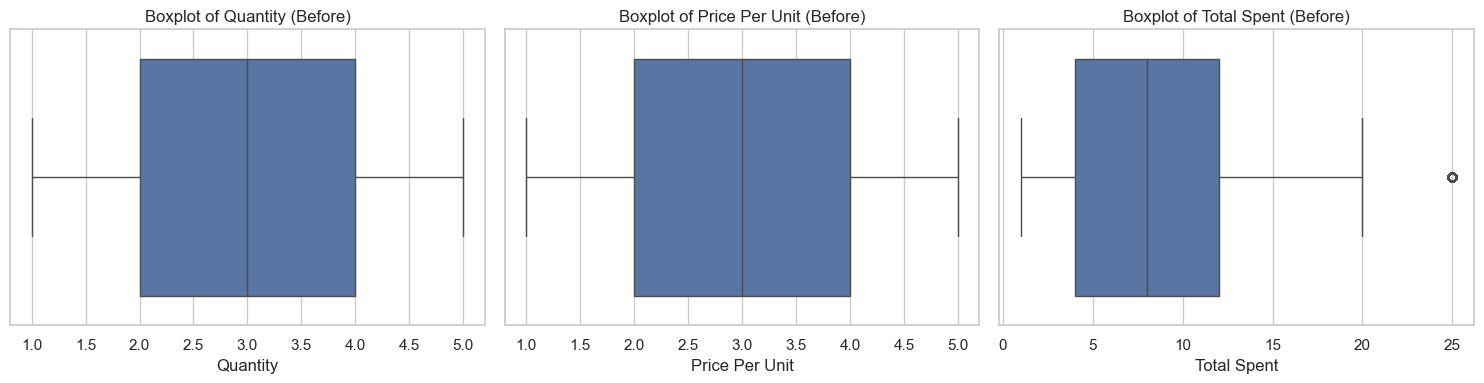

In [13]:
# Visualize before
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Quantity', 'Price Per Unit', 'Total Spent']):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} (Before)')
plt.tight_layout()
plt.show()

In [14]:
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, Lower={lower}, Upper={upper}, Outliers={len(outliers)}")

outliers.head()

Quantity: Q1=2.0, Q3=4.0, IQR=2.0, Lower=-1.0, Upper=7.0, Outliers=0
Price Per Unit: Q1=2.0, Q3=4.0, IQR=2.0, Lower=-1.0, Upper=7.0, Outliers=0
Total Spent: Q1=4.0, Q3=12.0, IQR=8.0, Lower=-8.0, Upper=24.0, Outliers=250


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
51,TXN_6342161,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-08
52,TXN_8914892,Juice,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-03-15
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10
100,TXN_9517146,Juice,5.0,5.0,25.0,Cash,Takeaway,2023-10-30


**Remove them**

In [15]:
df_clean = df.copy()
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f"Before outlier removal: {df.shape}")
print(f"After outlier removal:  {df_clean.shape}")

df_clean.head()

Before outlier removal: (9540, 8)
After outlier removal:  (9290, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [16]:
print(f"\nBefore outlier removal: {df.shape}")
print(f"After outlier removal:  {df_clean.shape}")


Before outlier removal: (9540, 8)
After outlier removal:  (9290, 8)


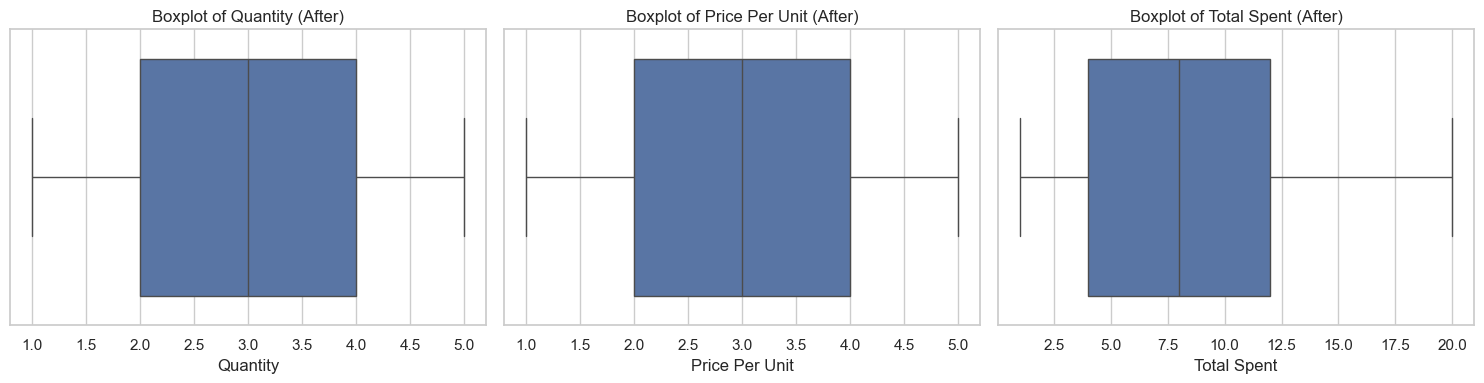

In [17]:
# Visualize after
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Quantity', 'Price Per Unit', 'Total Spent']):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} (After)')
plt.tight_layout()
plt.show()

**Outliers were detected using the IQR method. Only Total Spent had 250 outliers above
the upper bound of 24.0. These were removed, reducing the dataset from 9540 to 9290 rows.
Quantity and Price Per Unit had no outliers.**

## Task 5 - Normalization

**Min-Max Normalization**

In [18]:
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

# Min-Max Normalization
minmax_scaler = MinMaxScaler()
df_minmax = df_clean[numeric_cols].copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax)
print("Min-Max Normalized")
print(df_minmax.head())

Min-Max Normalized
   Quantity  Price Per Unit  Total Spent
0      0.25            0.25     0.157895
1      0.75            0.50     0.578947
2      0.75            0.00     0.368421
3      0.25            1.00     0.473684
4      0.25            0.25     0.157895


**Z-Score Normalization**

In [19]:
zscore_scaler = StandardScaler()
df_zscore = df_clean[numeric_cols].copy()
df_zscore[numeric_cols] = zscore_scaler.fit_transform(df_zscore)
print("\nZ-Score Standardized")
print(df_zscore.head())


Z-Score Standardized
   Quantity  Price Per Unit  Total Spent
0 -0.712984       -0.740797    -0.836726
1  0.751447        0.081377     0.672685
2  0.751447       -1.562970    -0.082020
3 -0.712984        1.725723     0.295332
4 -0.712984       -0.740797    -0.836726


**Min-Max normalization rescales values to [0,1] and is best for distance-based models
like KNN. Z-Score standardization centers data around 0 with std=1 and is best for
models like Linear Regression and PCA.**

## Task 6 - Correlation Check

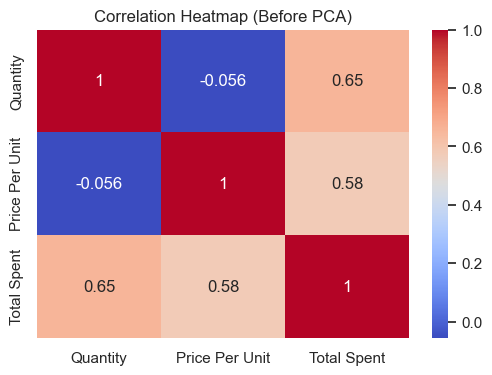

In [20]:
# Check correlation first
plt.figure(figsize=(6, 4))
sns.heatmap(df_zscore[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

**The heatmap shows Quantity and Total Spent have a correlation of 0.65, and Price Per Unit
and Total Spent have 0.58. Since features are moderately correlated, applying PCA is
justified as it can reduce overlapping information.**

## Task 7 PCA 

In [21]:
# Apply PCA
X = df_zscore[numeric_cols]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

In [22]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.61511607 0.35178654]
Total Variance Captured: 0.9669026163276908


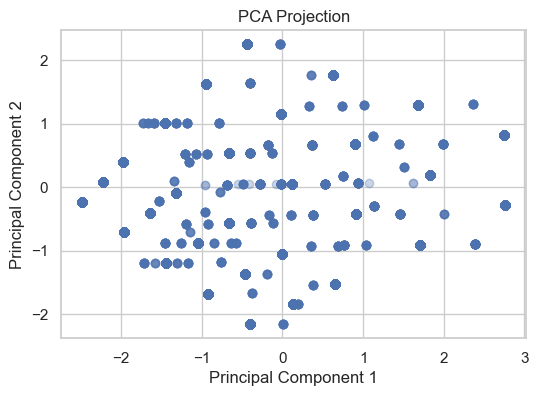

In [23]:
# Plot PCA projection
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.3)
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**PCA reduced 3 features to 2 principal components capturing 96.6% of the total variance
(PC1: 61.5%, PC2: 35.1%). This means only 3.4% of information is lost, making the
reduction effective and efficient.**